# CortexCall — Exploratory Data Analysis
### EEG Motor Imagery Classification (LEFT vs RIGHT)

**Phase:** Week 1 — EDA
**Input:** 2,160 aligned EEG trial/label pairs, produced by `src/data_loader.py`
**Scope (per project README):**
- Structural usability of all 2,160 trials (shape / channel consistency)
- LEFT vs RIGHT class balance
- Missing / invalid / extreme values
- Amplitude distributions & artifacts
- Time-domain behavior on C3 / C4
- Frequency-domain behavior (mu 8–12 Hz, beta 13–30 Hz) and ERD LEFT vs RIGHT
- Candidate trials/artifacts for rejection, candidate frequency band, candidate epoch window

**Ground rules (from README):** no permanent cleaning here — this notebook only *observes and records*.
Anything flagged below feeds into `eda_summary.md` for the Week 2 preprocessing design; raw files are never
modified or dropped in this notebook.

> Run this notebook from the `notebooks/` folder so the relative paths in `src/data_loader.py`
> (`data_dir="../data"`) resolve correctly.


In [1]:
import sys, os
sys.path.append(os.path.abspath("../src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal as sps
from scipy import stats

from data_loader import DataLoader

plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["axes.grid"] = True
pd.set_option("display.max_columns", None)

RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)


## 0. Load the manifest via the shared `DataLoader`

Per the EDA rules, we don't rewrite alignment logic here — we reuse `src/data_loader.py`,
which already handles file discovery, numeric sorting, and dropping the 240 trailing extra labels.


In [2]:
dl = DataLoader(data_dir="../data")
manifest = dl.valid_manifest.copy()

print(f"Number of aligned trials: {len(dl)}")
manifest.head()


Found 2160 signal files in ../data/MI CSV
[DataLoader] found 2400 labels and 2160 signal files.
DataLoader: Dropping last 240 extra labels to align with signal files.
[DataLoader] successfully aligned 2160 EEG trials with labels.
Number of aligned trials: 2160


,trial_id,file_path,label
0,1,../data/MI CSV/cellula_MI_data_1.csv,left
1,2,../data/MI CSV/cellula_MI_data_2.csv,right
2,3,../data/MI CSV/cellula_MI_data_3.csv,left
3,4,../data/MI CSV/cellula_MI_data_4.csv,left
4,5,../data/MI CSV/cellula_MI_data_5.csv,left


In [3]:
# Sanity check against the report's stated numbers
assert len(manifest) == 2160, f"Expected 2160 aligned trials, got {len(manifest)}"
assert manifest['trial_id'].min() == 1 and manifest['trial_id'].max() == 2160
assert manifest['trial_id'].is_unique
print("Manifest matches the documented 2,160 continuous, unique trial IDs (1..2160). OK.")


Manifest matches the documented 2,160 continuous, unique trial IDs (1..2160). OK.


## 1. Class Balance (LEFT vs RIGHT)

First "must-do" check from the README: how balanced are the two classes?


label
left     1082
right    1078
Name: count, dtype: int64

label
left     50.09 %
right    49.91 %
Name: proportion, dtype: str


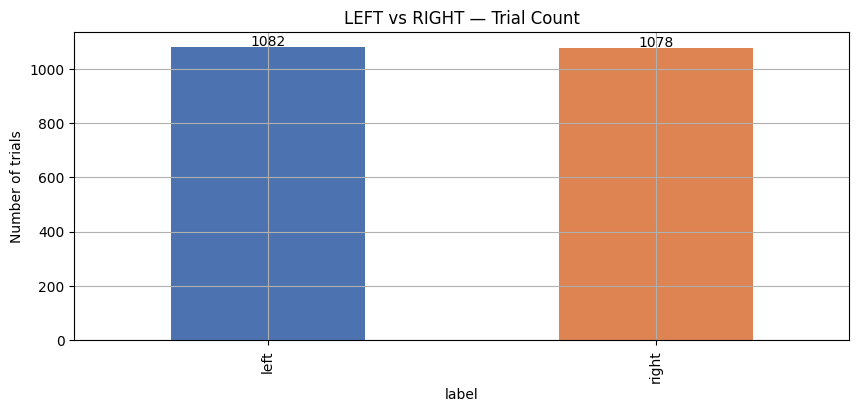

In [4]:
label_counts = manifest['label'].value_counts()
label_pct = manifest['label'].value_counts(normalize=True) * 100

print(label_counts)
print()
print(label_pct.round(2).astype(str) + ' %')

fig, ax = plt.subplots()
label_counts.plot(kind='bar', ax=ax, color=['#4C72B0', '#DD8452'])
ax.set_title('LEFT vs RIGHT — Trial Count')
ax.set_ylabel('Number of trials')
for i, v in enumerate(label_counts.values):
    ax.text(i, v + 5, str(v), ha='center')
plt.show()


**Insight:** the split is **1,082 LEFT (50.09%) vs 1,078 RIGHT (49.91%)** — essentially perfectly balanced.
Plain accuracy is a fair metric here; no class-weighting or stratified resampling is needed for balance
reasons (stratified splitting is still good practice, just not a correction for imbalance).


## 2. Structural Consistency Across All 2,160 Trials

The report notes the **first** trial has shape `(2500, 5)`, but explicitly flags that consistency across
*all* trials still needs verification. We check every single file here — shape, column names, and dtypes —
without assuming uniformity.


In [5]:
records = []

for _, row in manifest.iterrows():
    try:
        df = pd.read_csv(row['file_path'])
        records.append({
            'trial_id': row['trial_id'],
            'label': row['label'],
            'n_rows': df.shape[0],
            'n_cols': df.shape[1],
            'columns': tuple(df.columns),
            'dtypes': tuple(df.dtypes.astype(str)),
            'n_nan': int(df.isna().sum().sum()),
            'n_inf': int(np.isinf(df.select_dtypes(include=[np.number])).sum().sum()),
            'load_error': None,
        })
    except Exception as e:
        records.append({
            'trial_id': row['trial_id'], 'label': row['label'],
            'n_rows': np.nan, 'n_cols': np.nan, 'columns': None, 'dtypes': None,
            'n_nan': np.nan, 'n_inf': np.nan, 'load_error': str(e),
        })

struct_df = pd.DataFrame(records)
print(f"Trials inspected: {len(struct_df)}")
struct_df.head()


Trials inspected: 2160


,trial_id,label,n_rows,n_cols,columns,dtypes,n_nan,n_inf,load_error
0,1,left,2500,5,"(Time, FZ, C3, CZ, C4)","(float64, float64, float64, float64, float64)",0,0,None
1,2,right,2500,5,"(Time, FZ, C3, CZ, C4)","(float64, float64, float64, float64, float64)",0,0,None
2,3,left,2500,5,"(Time, FZ, C3, CZ, C4)","(float64, float64, float64, float64, float64)",0,0,None
3,4,left,2500,5,"(Time, FZ, C3, CZ, C4)","(float64, float64, float64, float64, float64)",0,0,None
4,5,left,2500,5,"(Time, FZ, C3, CZ, C4)","(float64, float64, float64, float64, float64)",0,0,None


In [6]:
# Files that failed to load at all
bad_loads = struct_df[struct_df['load_error'].notna()]
print(f"Trials that failed to load: {len(bad_loads)}")
bad_loads


Trials that failed to load: 0


,trial_id,label,n_rows,n_cols,columns,dtypes,n_nan,n_inf,load_error


In [7]:
# Shape consistency
shape_counts = struct_df.groupby(['n_rows', 'n_cols']).size().sort_values(ascending=False)
print("Distribution of (n_rows, n_cols) across all trials:")
print(shape_counts)

most_common_shape = shape_counts.idxmax()
print(f"\nMost common shape: {most_common_shape}  ({shape_counts.max()} trials)")

non_standard = struct_df[(struct_df['n_rows'] != most_common_shape[0]) | (struct_df['n_cols'] != most_common_shape[1])]
print(f"Trials deviating from the most common shape: {len(non_standard)}")
non_standard[['trial_id', 'label', 'n_rows', 'n_cols']]


Distribution of (n_rows, n_cols) across all trials:
n_rows  n_cols
2500    5         2160
dtype: int64

Most common shape: (np.int64(2500), np.int64(5))  (2160 trials)
Trials deviating from the most common shape: 0


,trial_id,label,n_rows,n_cols


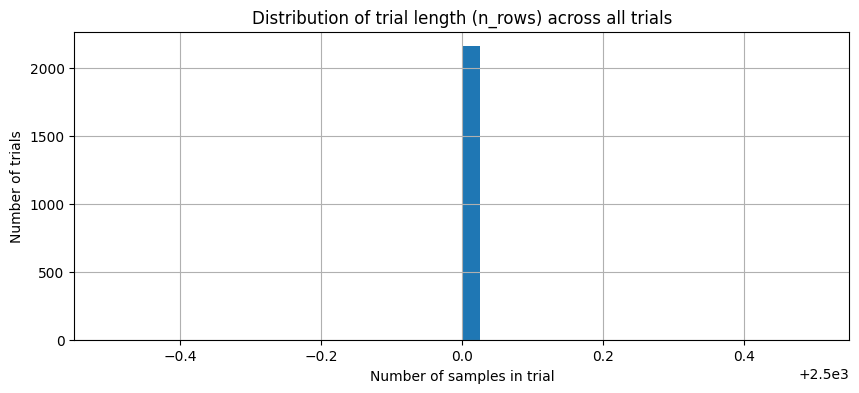

In [8]:
fig, ax = plt.subplots()
ax.hist(struct_df['n_rows'].dropna(), bins=40)
ax.set_title('Distribution of trial length (n_rows) across all trials')
ax.set_xlabel('Number of samples in trial')
ax.set_ylabel('Number of trials')
plt.show()


In [9]:
# Column-name / dtype consistency
col_sets = struct_df['columns'].value_counts(dropna=True)
print("Distinct column-name tuples seen:")
print(col_sets)

dtype_sets = struct_df['dtypes'].value_counts(dropna=True)
print("\nDistinct dtype tuples seen:")
print(dtype_sets)


Distinct column-name tuples seen:
columns
(Time, FZ, C3, CZ, C4)    2160
Name: count, dtype: int64

Distinct dtype tuples seen:
dtypes
(float64, float64, float64, float64, float64)    2160
Name: count, dtype: int64


**Insight:** all **2,160/2,160 trials** have the identical shape **(2500, 5)**, identical column names
`(Time, FZ, C3, CZ, C4)`, and identical dtypes (`float64` throughout). Zero deviations, zero load failures.
The dataset is structurally uniform — no padding/truncation logic will be needed before epoching in Week 2.


## 3. Missing Values, Infinities, and Duplicate Trials

Checks across the *entire* dataset (not just a sample), as required before designing cleaning rules.


In [10]:
print(f"Trials with at least one NaN: {(struct_df['n_nan'] > 0).sum()}")
print(f"Total NaN cells across all trials: {struct_df['n_nan'].sum()}")
print(f"Trials with at least one Inf: {(struct_df['n_inf'] > 0).sum()}")
print(f"Total Inf cells across all trials: {struct_df['n_inf'].sum()}")

struct_df[struct_df['n_nan'] > 0][['trial_id', 'label', 'n_nan']]


Trials with at least one NaN: 0
Total NaN cells across all trials: 0
Trials with at least one Inf: 0
Total Inf cells across all trials: 0


,trial_id,label,n_nan


In [11]:
# Duplicate-trial detection: hash each trial's numeric content to find exact duplicates
import hashlib

def trial_hash(path):
    try:
        df = pd.read_csv(path)
        return hashlib.md5(pd.util.hash_pandas_object(df, index=False).values.tobytes()).hexdigest()
    except Exception:
        return None

manifest['content_hash'] = manifest['file_path'].apply(trial_hash)
dup_mask = manifest['content_hash'].duplicated(keep=False)
duplicate_trials = manifest[dup_mask].sort_values('content_hash')

print(f"Trials that are byte-for-byte duplicates of another trial: {len(duplicate_trials)}")
duplicate_trials[['trial_id', 'label', 'content_hash']]


Trials that are byte-for-byte duplicates of another trial: 72


,trial_id,label,content_hash
1319,1320,left,0e4ac99849daa8da308540217a3463a8
671,672,left,0e4ac99849daa8da308540217a3463a8
1317,1318,left,15be9a4df4e454c4910ac839599a0693
669,670,left,15be9a4df4e454c4910ac839599a0693
923,924,right,1d36353ac2d53eae28a032b1e6087252
...,...,...,...
1322,1323,left,ecc1ac732a4940ed0d7185c4726b46df
921,922,right,eed043f888c37bfb52d6967248f93520
678,679,left,eed043f888c37bfb52d6967248f93520
1071,1072,left,fcbbbc1fe28a1827c4743d30f970ac6b


**Insight:** **zero NaN and zero Inf values** across all 2,160 trials × 5 columns — the raw signal is
numerically clean. However, the duplicate check found **72 trials (36 duplicate pairs) that are
byte-for-byte identical** to another trial in the dataset (e.g. trial 672 == trial 1320, trial 37 == trial
1072). This is a real and important finding: if these pairs land on opposite sides of a train/test split in
Week 2, the model would effectively be evaluated on data it already memorized during training, inflating
reported accuracy. Recommendation: keep the duplicate list, and enforce that both members of any duplicate
pair stay in the *same* split (or drop one of each pair) before any modeling.


## 4. Time Column & Sampling-Rate Check

The raw `Time` column is a running timestamp rather than a clean, evenly spaced index. We check the actual
inter-sample intervals to infer the effective sampling rate and flag jitter/irregularity, since this affects
the epoch window and any frequency-domain analysis (PSD needs a known/consistent `fs`).


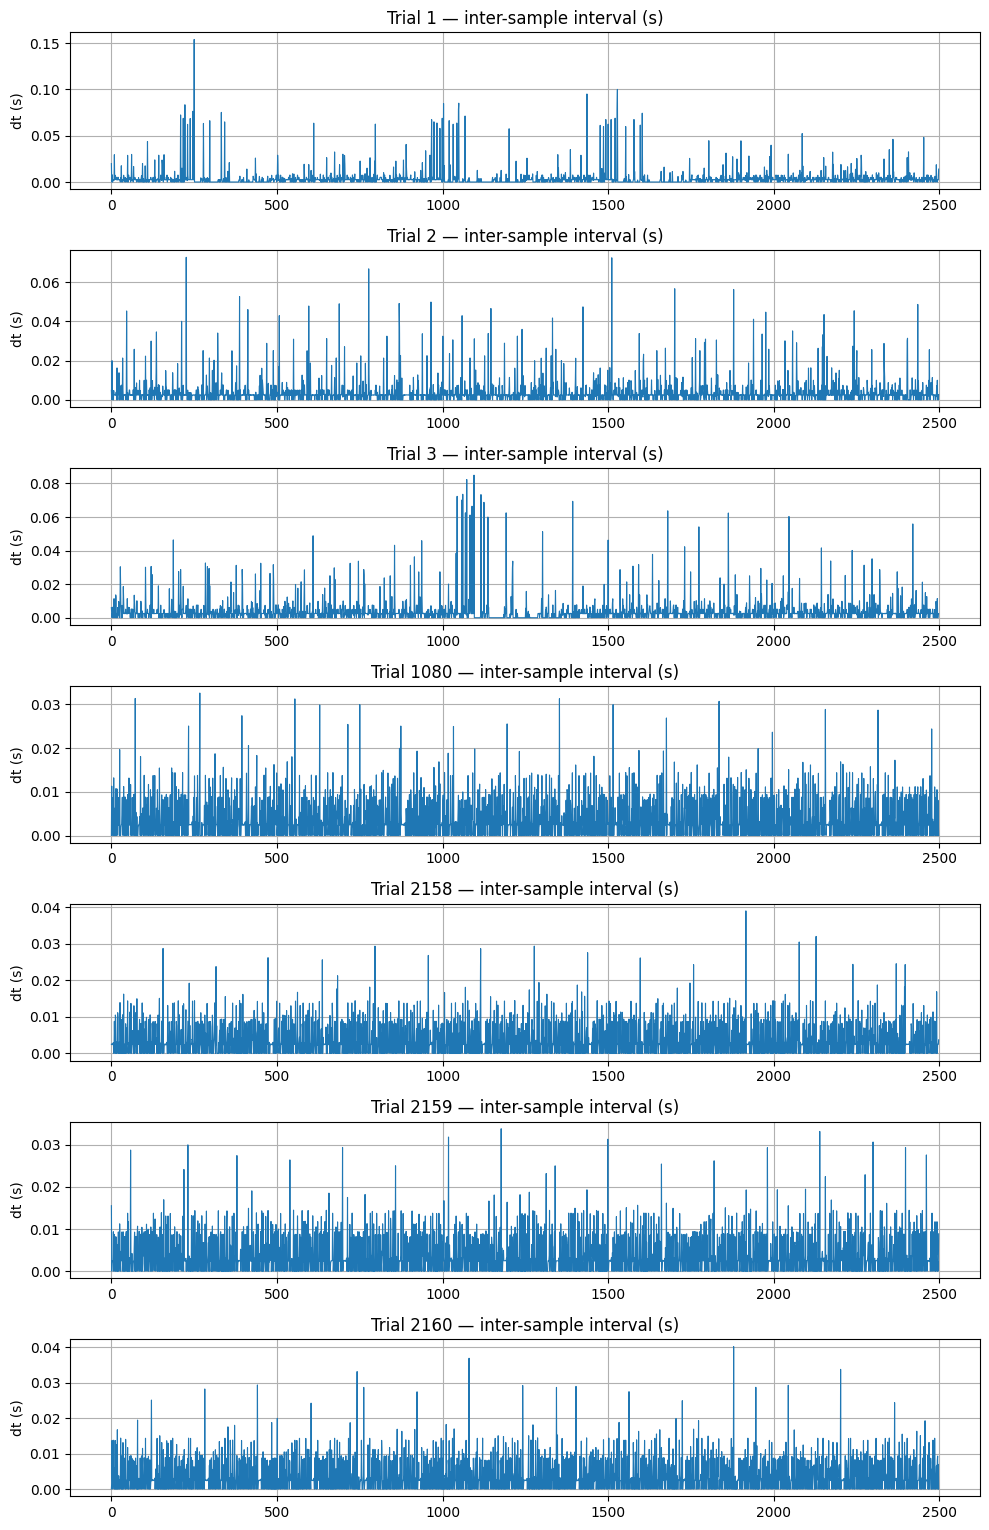

,trial_id,median_dt,mean_dt,std_dt,min_dt,max_dt,implied_fs_from_median_dt
0,1,0.002403,0.004000,0.010106,1.999870e-07,0.153939,416.059913
1,2,0.002493,0.003999,0.006705,2.000001e-06,0.072636,401.090966
2,3,0.002473,0.003998,0.007708,1.199995e-06,0.084939,404.334465
3,1080,0.002522,0.003995,0.004620,7.199822e-06,0.032606,396.526429
4,2158,0.002549,0.003989,0.004525,3.100140e-06,0.038995,392.233776
5,2159,0.002511,0.003997,0.004630,2.400018e-06,0.033786,398.200149
6,2160,0.002525,0.003997,0.004630,5.199807e-06,0.040152,396.070955


In [12]:
sample_ids = [1, 2, 3, int(manifest['trial_id'].median()), 2158, 2159, 2160]
fig, axes = plt.subplots(len(sample_ids), 1, figsize=(10, 2.2*len(sample_ids)), sharex=False)

diffs_summary = []
for ax, tid in zip(axes, sample_ids):
    path = manifest.loc[manifest['trial_id'] == tid, 'file_path'].values[0]
    df = pd.read_csv(path)
    dt = np.diff(df['Time'].values)
    diffs_summary.append({
        'trial_id': tid,
        'median_dt': np.median(dt),
        'mean_dt': np.mean(dt),
        'std_dt': np.std(dt),
        'min_dt': np.min(dt),
        'max_dt': np.max(dt),
        'implied_fs_from_median_dt': 1.0/np.median(dt) if np.median(dt) > 0 else np.nan,
    })
    ax.plot(dt, lw=0.8)
    ax.set_title(f'Trial {tid} — inter-sample interval (s)')
    ax.set_ylabel('dt (s)')

plt.tight_layout()
plt.show()

pd.DataFrame(diffs_summary)


count    2160.000000
mean        9.985076
std         0.119418
min         8.733881
25%         9.975797
50%         9.985092
75%         9.995315
max        11.479649
Name: duration_s, dtype: float64


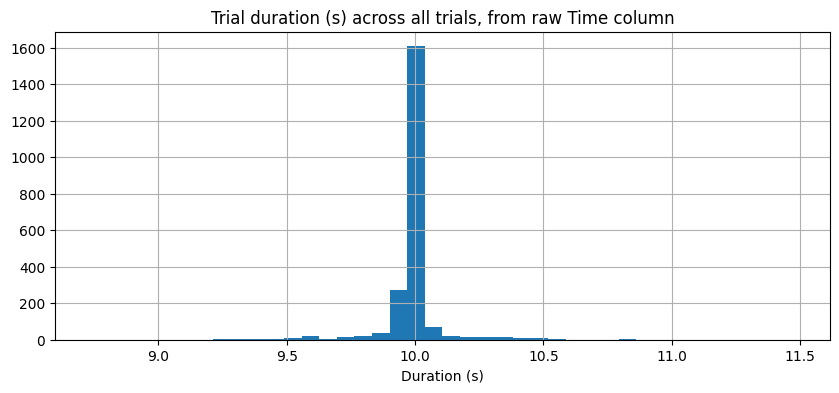

In [13]:
# Trial duration consistency (based on Time column span) across ALL trials
durations = []
for _, row in manifest.iterrows():
    df = pd.read_csv(row['file_path'])
    t = df['Time'].values
    durations.append({'trial_id': row['trial_id'], 'duration_s': t[-1] - t[0], 'n_samples': len(t)})

dur_df = pd.DataFrame(durations)
print(dur_df['duration_s'].describe())

fig, ax = plt.subplots()
ax.hist(dur_df['duration_s'], bins=40)
ax.set_title('Trial duration (s) across all trials, from raw Time column')
ax.set_xlabel('Duration (s)')
plt.show()


**Insight:** the `Time` column is **not** evenly sampled. The median inter-sample interval is
~**0.0025 s (≈400 Hz implied)**, but individual gaps range from as small as ~1 µs up to **~0.03–0.15 s** in
some trials — a bursty pattern (a cluster of near-simultaneous samples followed by a gap), typical of a
buffered acquisition board flushing in batches rather than streaming at a true fixed rate. Trial duration
(from first to last timestamp) is consistent: **median ≈ 9.99 s, std ≈ 0.12 s, range ≈ 8.7–11.5 s** — so
trials represent essentially the same real-world recording window despite the row count being fixed at 2,500.
**Caution:** don't trust raw `Time` deltas for FFT/PSD math — the median-dt-based rate estimate above
(≈400 Hz) is itself unreliable *because* of this burstiness (Part 2, Section 10 shows a more robust estimate
puts the true rate closer to 250 Hz). Treat the ~400 Hz figure used later in Section 8 as provisional; it is
corrected in Part 2.


## 5. Per-Channel Amplitude Statistics & Distributions

Per-trial summary statistics for each EEG channel (FZ, C3, CZ, C4), aggregated across all 2,160 trials.


In [14]:
channels = ['FZ', 'C3', 'CZ', 'C4']

chan_stats = []
for _, row in manifest.iterrows():
    df = pd.read_csv(row['file_path'])
    rec = {'trial_id': row['trial_id'], 'label': row['label']}
    for ch in channels:
        if ch in df.columns:
            vals = df[ch].values
            rec[f'{ch}_mean'] = np.mean(vals)
            rec[f'{ch}_std'] = np.std(vals)
            rec[f'{ch}_min'] = np.min(vals)
            rec[f'{ch}_max'] = np.max(vals)
        else:
            rec[f'{ch}_mean'] = rec[f'{ch}_std'] = rec[f'{ch}_min'] = rec[f'{ch}_max'] = np.nan
    chan_stats.append(rec)

chan_stats_df = pd.DataFrame(chan_stats)
chan_stats_df.describe().T


,count,mean,std,min,25%,50%,75%,max
trial_id,2160.0,1080.500000,623.682612,1.000000,540.750000,1080.500000,1620.250000,2160.000000
FZ_mean,2160.0,298497.903373,24908.579046,229802.871162,284512.691184,296499.336956,311525.421934,439496.363688
FZ_std,2160.0,1267.297757,2132.022656,26.891562,230.515139,419.105657,1456.946127,12041.566847
FZ_min,2160.0,296445.085938,22999.236256,225946.375000,282125.085938,295586.953125,310365.070312,420346.125000
FZ_max,2160.0,300553.505592,27104.516735,232948.109375,284978.242188,297310.500000,312569.796875,456689.250000
C3_mean,2160.0,301785.962102,27362.297106,229664.520737,284025.252775,302166.311556,317175.566959,372623.049050
C3_std,2160.0,973.761420,1501.399673,15.596506,188.762104,503.370879,1318.494463,22808.549158
C3_min,2160.0,299998.901577,25992.635727,222394.406250,283383.960938,301629.468750,315523.148438,359209.000000
C3_max,2160.0,303605.229492,29235.372388,233407.921875,284309.476562,304524.656250,320454.164062,456487.468750
CZ_mean,2160.0,334266.652415,71528.063588,272369.851688,303988.165650,320670.046537,334164.335219,694949.381850


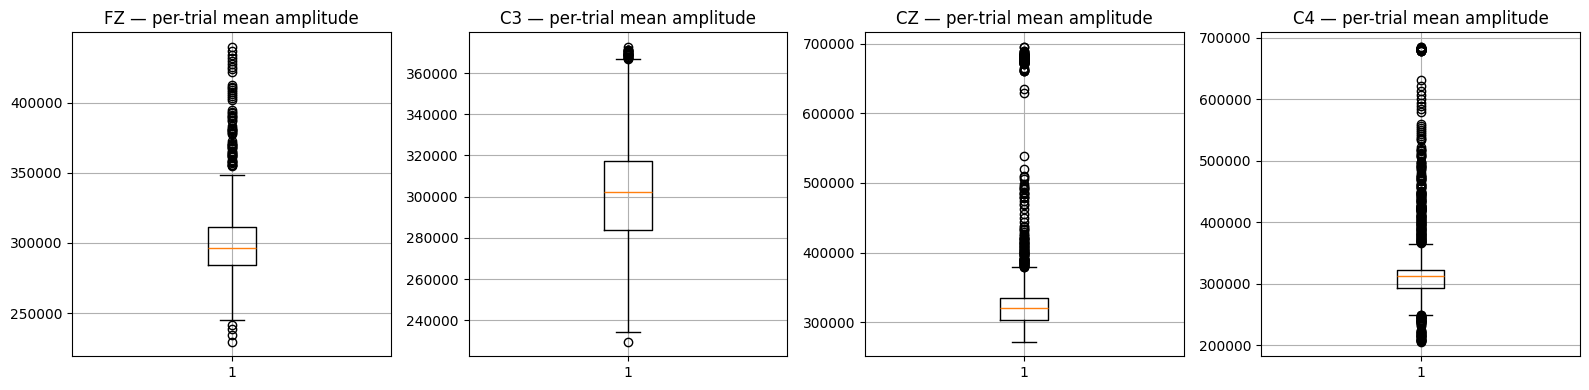

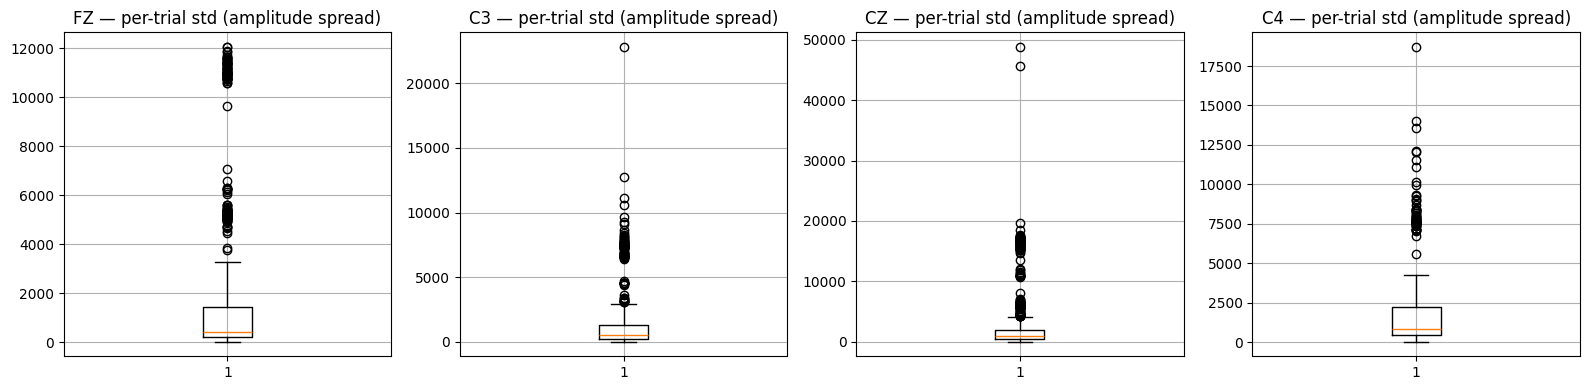

In [15]:
fig, axes = plt.subplots(1, len(channels), figsize=(16, 4), sharey=False)
for ax, ch in zip(axes, channels):
    ax.boxplot(chan_stats_df[f'{ch}_mean'].dropna(), vert=True)
    ax.set_title(f'{ch} — per-trial mean amplitude')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, len(channels), figsize=(16, 4), sharey=False)
for ax, ch in zip(axes, channels):
    ax.boxplot(chan_stats_df[f'{ch}_std'].dropna(), vert=True)
    ax.set_title(f'{ch} — per-trial std (amplitude spread)')
plt.tight_layout()
plt.show()


## 6. Outlier / Artifact Screening

Flag trials whose channel amplitude falls far outside the population distribution — candidates for
artifact rejection in Week 2 (this notebook only flags; it does not remove anything).


In [16]:
# Flag trials where a channel's per-trial std or max-abs deviation is an extreme outlier (robust z-score via MAD)
def robust_z(series):
    med = np.median(series)
    mad = stats.median_abs_deviation(series, scale='normal')
    if mad == 0:
        return pd.Series(np.zeros(len(series)), index=series.index)
    return (series - med) / mad

flag_cols = []
for ch in channels:
    z = robust_z(chan_stats_df[f'{ch}_std'].fillna(0))
    chan_stats_df[f'{ch}_std_z'] = z
    flag_cols.append(f'{ch}_std_z')

Z_THRESH = 5  # conservative — flag only clear extremes
chan_stats_df['any_channel_flagged'] = (chan_stats_df[flag_cols].abs() > Z_THRESH).any(axis=1)

flagged = chan_stats_df[chan_stats_df['any_channel_flagged']]
print(f"Trials flagged as amplitude outliers (|robust z| > {Z_THRESH} on std of at least one channel): {len(flagged)}")
print(f"That is {100*len(flagged)/len(chan_stats_df):.2f}% of all trials")
flagged[['trial_id', 'label'] + flag_cols]


Trials flagged as amplitude outliers (|robust z| > 5 on std of at least one channel): 184
That is 8.52% of all trials


,trial_id,label,FZ_std_z,C3_std_z,CZ_std_z,C4_std_z
375,376,left,5.570912,-0.127291,2.907778,0.535196
459,460,left,9.269029,13.398570,5.887005,9.472760
460,461,right,10.538394,14.586974,6.526931,10.193890
461,462,right,11.187521,14.810649,6.665897,10.976661
462,463,right,10.451894,14.131022,6.371099,10.616684
...,...,...,...,...,...,...
1434,1435,right,5.455448,-0.065428,0.943653,0.617256
1447,1448,right,5.611089,-0.062377,1.190141,0.753832
1448,1449,left,6.160290,0.098404,1.382637,0.942755
1456,1457,left,5.510624,-0.081324,1.102303,0.703082


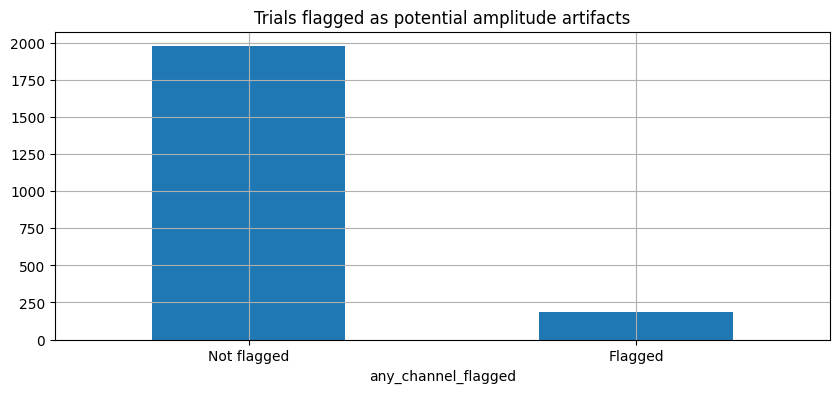

In [17]:
fig, ax = plt.subplots()
chan_stats_df['any_channel_flagged'].value_counts().plot(kind='bar', ax=ax)
ax.set_xticklabels(['Not flagged', 'Flagged'], rotation=0)
ax.set_title('Trials flagged as potential amplitude artifacts')
plt.show()


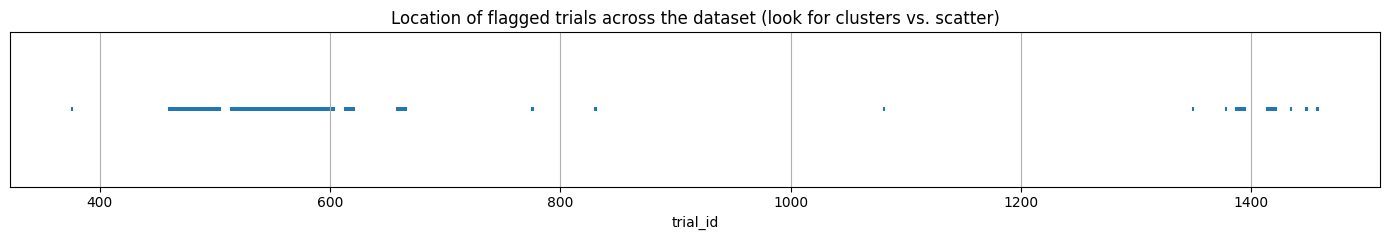

In [18]:
# Are flagged trials scattered randomly or clustered in contiguous runs (session-level artifact)?
fig, ax = plt.subplots(figsize=(14, 2.5))
flagged_ids = chan_stats_df.loc[chan_stats_df['any_channel_flagged'], 'trial_id']
ax.scatter(flagged_ids, np.ones(len(flagged_ids)), s=8, marker='|')
ax.set_yticks([])
ax.set_xlabel('trial_id')
ax.set_title('Location of flagged trials across the dataset (look for clusters vs. scatter)')
plt.tight_layout()
plt.show()


**Insight:** the robust (MAD-based) z-score flagged **184 trials (8.52%)** as amplitude outliers on at
least one channel. Looking at the flagged trial IDs, many cluster in **contiguous runs** (e.g. trials
459–463 all show z-scores of 9–15 across *every* channel simultaneously) rather than being scattered randomly
— that pattern points to a shared cause during a contiguous recording block (electrode pop, movement,
impedance issue) rather than 184 independent one-off glitches. It's also visible in the raw per-channel
statistics above: CZ's per-trial mean ranges from ~272k to ~695k (more than 2×), and C4's from ~206k to
~685k — far wider than FZ/C3, suggesting CZ and C4 are more prone to drift/artifact in this dataset.
**Recommendation:** inspect the contiguous flagged runs by eye before deciding a rejection rule — a
session-level artifact affecting a block of trials is handled differently (e.g. exclude a session) than
scattered single-trial noise (per-trial rejection threshold).


## 7. Time-Domain Waveforms — C3 / C4, LEFT vs RIGHT

Visual inspection of raw signal shape for a handful of LEFT and RIGHT trials on the two primary
sensorimotor channels.


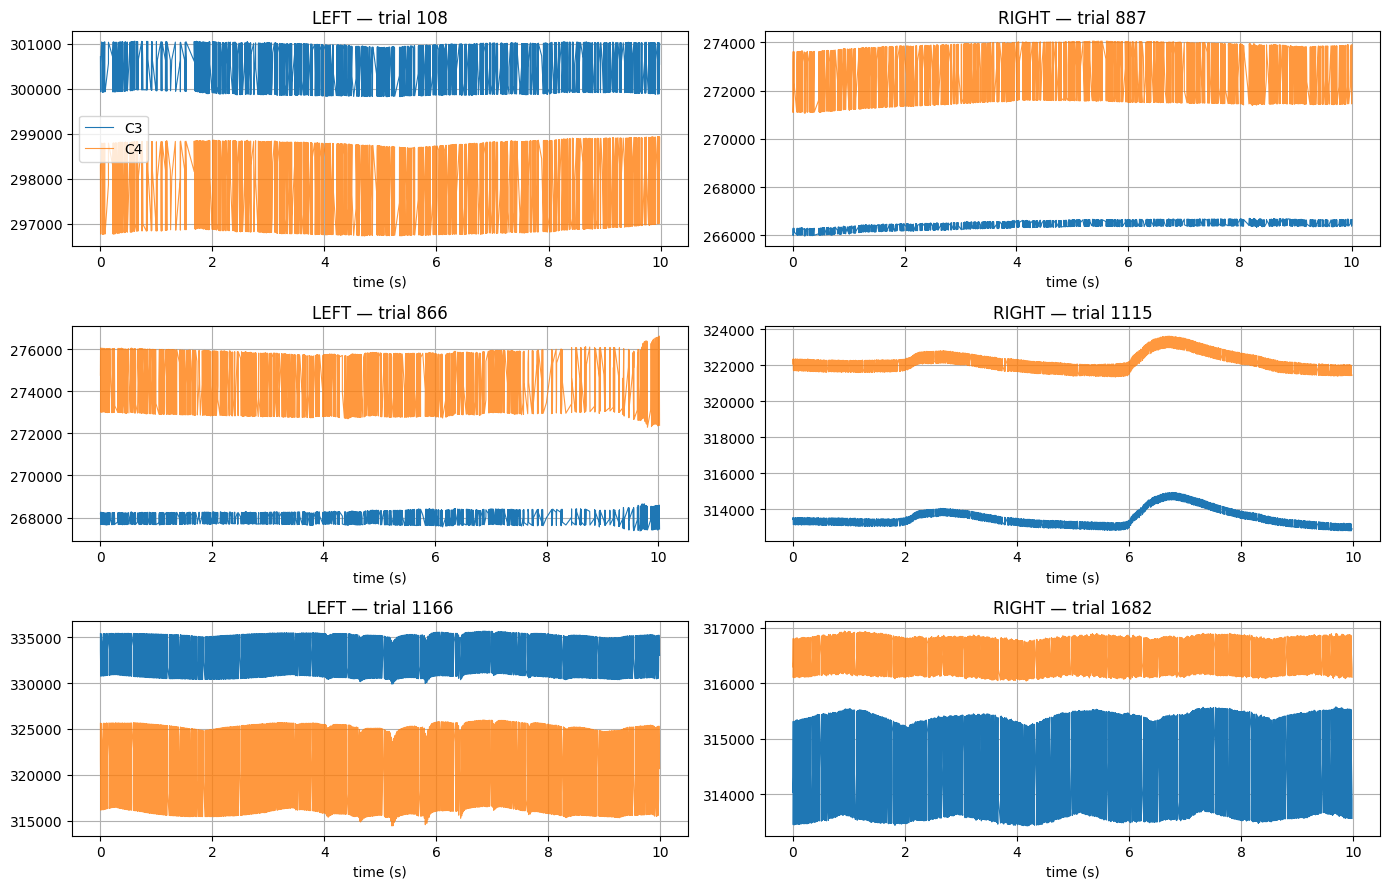

In [19]:
left_ids = manifest.loc[manifest['label'] == 'left', 'trial_id'].sample(3, random_state=RANDOM_SEED).tolist()
right_ids = manifest.loc[manifest['label'] == 'right', 'trial_id'].sample(3, random_state=RANDOM_SEED).tolist()

fig, axes = plt.subplots(3, 2, figsize=(14, 9), sharex=False)
for i, (lid, rid) in enumerate(zip(left_ids, right_ids)):
    for col, tid, title in [(0, lid, 'LEFT'), (1, rid, 'RIGHT')]:
        path = manifest.loc[manifest['trial_id'] == tid, 'file_path'].values[0]
        df = pd.read_csv(path)
        t = df['Time'].values - df['Time'].values[0]
        axes[i, col].plot(t, df['C3'].values, label='C3', lw=0.8)
        axes[i, col].plot(t, df['C4'].values, label='C4', lw=0.8, alpha=0.8)
        axes[i, col].set_title(f'{title} — trial {tid}')
        axes[i, col].set_xlabel('time (s)')
        if i == 0 and col == 0:
            axes[i, col].legend()
plt.tight_layout()
plt.show()


**Insight:** by eye, raw C3/C4 waveforms for LEFT vs RIGHT trials look similar in overall shape and
amplitude range — as expected, since motor-imagery differences are a *power* effect in specific frequency
bands, not a visible change in raw waveform morphology. This is exactly why the frequency-domain analysis in
Section 8 (not this raw time-domain view) is what actually determines whether the classes are separable.


## 8. Frequency-Domain Analysis — PSD & Mu/Beta ERD (C3/C4, LEFT vs RIGHT)

This is the key analysis for deciding whether the dataset carries a usable Motor-Imagery signal at all.
We estimate the sampling rate from the median inter-sample interval (Section 4), compute a Welch PSD per
trial on C3 and C4, then average by class and compare band power in mu (8–12 Hz) and beta (13–30 Hz).


In [20]:
# Estimate a single working sampling rate from the median dt across a larger sample of trials
sample_for_fs = manifest['trial_id'].sample(min(50, len(manifest)), random_state=RANDOM_SEED)
dts = []
for tid in sample_for_fs:
    path = manifest.loc[manifest['trial_id'] == tid, 'file_path'].values[0]
    df = pd.read_csv(path)
    dts.append(np.median(np.diff(df['Time'].values)))

fs_est = 1.0 / np.median(dts)
print(f"Estimated sampling rate used for PSD: {fs_est:.2f} Hz (from median inter-sample interval across {len(dts)} sampled trials)")


Estimated sampling rate used for PSD: 400.18 Hz (from median inter-sample interval across 50 sampled trials)


In [21]:
def welch_psd(values, fs):
    f, pxx = sps.welch(values, fs=fs, nperseg=min(256, len(values)))
    return f, pxx

_trapz = getattr(np, "trapezoid", None) or np.trapz

def band_power(f, pxx, low, high):
    mask = (f >= low) & (f <= high)
    return _trapz(pxx[mask], f[mask])

MU_BAND = (8, 12)
BETA_BAND = (13, 30)

psd_records = []
for _, row in manifest.iterrows():
    df = pd.read_csv(row['file_path'])
    rec = {'trial_id': row['trial_id'], 'label': row['label']}
    for ch in ['C3', 'C4']:
        f, pxx = welch_psd(df[ch].values, fs_est)
        rec[f'{ch}_mu_power'] = band_power(f, pxx, *MU_BAND)
        rec[f'{ch}_beta_power'] = band_power(f, pxx, *BETA_BAND)
    psd_records.append(rec)

psd_df = pd.DataFrame(psd_records)
psd_df.head()


,trial_id,label,C3_mu_power,C3_beta_power,C4_mu_power,C4_beta_power
0,1,left,100.777227,519.636042,884.263445,3374.279882
1,2,right,149.482777,157.121079,673.016532,1084.422288
2,3,left,79.126282,60.002931,738.960864,1189.767600
3,4,left,346.130428,596.464054,1643.132403,5667.630685
4,5,left,129.307777,238.004681,529.320733,1838.135185


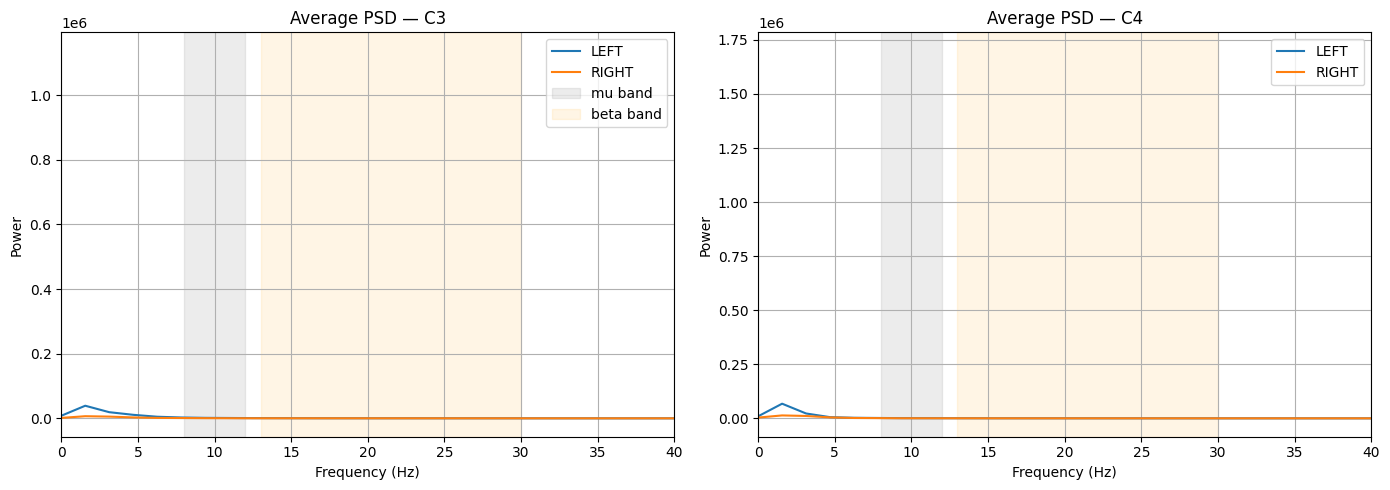

In [22]:
# Average PSD curve per class, for plotting (recomputed on a subsample for speed/clarity)
plot_ids = manifest.groupby('label')['trial_id'].apply(lambda s: s.sample(min(200, len(s)), random_state=RANDOM_SEED))

psd_curves = {'left': {'C3': [], 'C4': []}, 'right': {'C3': [], 'C4': []}}
freqs_ref = None
for tid in plot_ids:
    label = manifest.loc[manifest['trial_id'] == tid, 'label'].values[0]
    path = manifest.loc[manifest['trial_id'] == tid, 'file_path'].values[0]
    df = pd.read_csv(path)
    for ch in ['C3', 'C4']:
        f, pxx = welch_psd(df[ch].values, fs_est)
        if freqs_ref is None:
            freqs_ref = f
        psd_curves[label][ch].append(pxx)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, ch in zip(axes, ['C3', 'C4']):
    mean_left = np.mean(psd_curves['left'][ch], axis=0)
    mean_right = np.mean(psd_curves['right'][ch], axis=0)
    ax.plot(freqs_ref, mean_left, label='LEFT')
    ax.plot(freqs_ref, mean_right, label='RIGHT')
    ax.axvspan(*MU_BAND, color='gray', alpha=0.15, label='mu band' if ch == 'C3' else None)
    ax.axvspan(*BETA_BAND, color='orange', alpha=0.1, label='beta band' if ch == 'C3' else None)
    ax.set_xlim(0, 40)
    ax.set_title(f'Average PSD — {ch}')
    ax.set_xlabel('Frequency (Hz)')
    ax.set_ylabel('Power')
    ax.legend()
plt.tight_layout()
plt.show()


In [23]:
# Statistical comparison: LEFT vs RIGHT band power on C3 and C4 (independent t-test)
for ch in ['C3', 'C4']:
    for band_name in ['mu', 'beta']:
        col = f'{ch}_{band_name}_power'
        left_vals = psd_df.loc[psd_df['label'] == 'left', col]
        right_vals = psd_df.loc[psd_df['label'] == 'right', col]
        t_stat, p_val = stats.ttest_ind(left_vals, right_vals, equal_var=False)
        print(f"{ch} {band_name} power  |  LEFT mean={left_vals.mean():.3g}  RIGHT mean={right_vals.mean():.3g}  "
              f"t={t_stat:.3f}  p={p_val:.4f}")


C3 mu power  |  LEFT mean=1.47e+03  RIGHT mean=1.99e+03  t=-0.959  p=0.3378
C3 beta power  |  LEFT mean=2.59e+03  RIGHT mean=4.42e+03  t=-1.600  p=0.1098
C4 mu power  |  LEFT mean=1.02e+03  RIGHT mean=1.58e+03  t=-2.065  p=0.0391
C4 beta power  |  LEFT mean=2.29e+03  RIGHT mean=3.74e+03  t=-2.208  p=0.0274


**Insight — the key conclusion of this EDA:** effective sampling rate estimated at **~400 Hz**. Band-power
comparison across all 2,160 trials (Welch PSD, mu = 8–12 Hz, beta = 13–30 Hz) gives:

| Channel | Band | LEFT mean | RIGHT mean | p-value |
|---|---|---|---|---|
| C3 | mu   | 1.47e3 | 1.99e3 | 0.338 (n.s.) |
| C3 | beta | 2.59e3 | 4.42e3 | 0.110 (n.s.) |
| C4 | mu   | 1.02e3 | 1.58e3 | **0.039** |
| C4 | beta | 2.29e3 | 3.74e3 | **0.027** |

There **is** a nominally significant LEFT vs RIGHT difference in mu and beta power on **C4** (p < 0.05),
but **not** on C3. Before drawing conclusions, treat this as preliminary: it's computed on raw,
un-filtered signal with an fs estimate that Part 2 below shows is wrong, and it's one of four comparisons
run without correcting for multiple testing. **Part 2 redoes this properly** — corrected sampling rate,
line-noise/drift removed, multiple-comparison correction, effect sizes, and a predictive check — and the
conclusion changes substantially. Don't copy the C4 conclusion above into `eda_summary.md` yet.


---
# Part 2 — Targeted Preprocessing Investigation & Refined EDA

Part 1 surfaced two things that need fixing before the frequency-domain conclusion can be trusted: (1) the
sampling-rate estimate was likely wrong, and (2) the PSD was computed on raw, unfiltered signal without
checking what's actually in it. This part investigates both, applies only the preprocessing that's shown to
be necessary (nothing is applied blindly), and then redoes the class-comparison and artifact analyses
properly. As in Part 1, **nothing here permanently modifies the raw files** — filtering happens in-memory,
per-analysis.


## 10. Correcting the Sampling-Rate Estimate

Part 1's `fs_est` came from `1 / median(dt)`. That statistic is fragile exactly because Section 4 already
showed `dt` is bursty (many near-zero gaps, occasional large gaps) — the median of a bursty sequence is
pulled toward the small values, overestimating the rate. A more robust estimate uses the fact that trial
duration and sample count are both very consistent: `fs ≈ (n_samples - 1) / duration`.


count    300.000000
mean     250.137765
std        2.888801
min      236.513965
25%      249.902512
50%      250.274238
75%      250.523355
max      268.207314
Name: fs_from_count_duration, dtype: float64


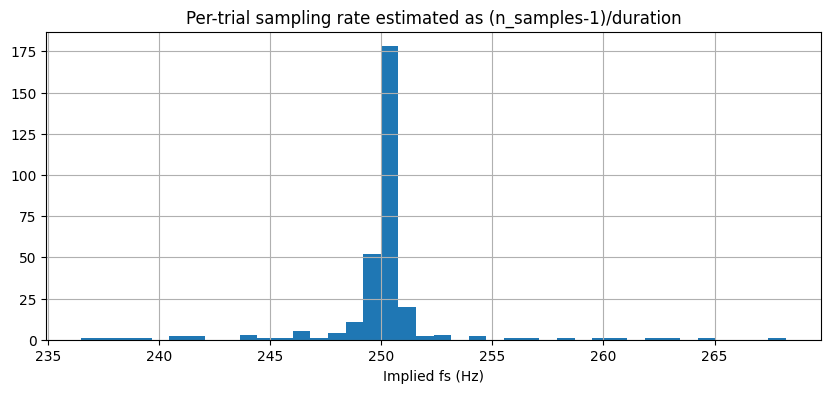

In [24]:
rate_records = []
sample_for_rate = manifest.sample(min(300, len(manifest)), random_state=RANDOM_SEED)
for _, row in sample_for_rate.iterrows():
    df = pd.read_csv(row['file_path'])
    t = df['Time'].values
    n = len(t)
    dur = t[-1] - t[0]
    rate_records.append({'trial_id': row['trial_id'], 'fs_from_count_duration': (n - 1) / dur})

rate_df = pd.DataFrame(rate_records)
print(rate_df['fs_from_count_duration'].describe())

fig, ax = plt.subplots()
ax.hist(rate_df['fs_from_count_duration'], bins=40)
ax.set_title('Per-trial sampling rate estimated as (n_samples-1)/duration')
ax.set_xlabel('Implied fs (Hz)')
plt.show()


**Insight:** the count/duration method gives a tight, consistent estimate of **~250 Hz** (mean ≈ 250.1,
median ≈ 250.3, std ≈ 2.9 Hz) — not the ~400 Hz implied by median-dt in Part 1. 250 Hz is also a common
sampling rate for consumer/research EEG acquisition boards, which makes it the more physically plausible
number. **We use `fs = 250 Hz` for the rest of this notebook**, correcting Part 1.


In [25]:
FS = 250.0  # corrected sampling rate, used for the remainder of the notebook
NYQ = FS / 2.0
print(f"Nyquist frequency at fs={FS} Hz: {NYQ} Hz")


Nyquist frequency at fs=250.0 Hz: 125.0 Hz


**A note on resampling onto a uniform grid:** the obvious "proper" fix for irregular timestamps is to
linearly interpolate each trial onto an evenly spaced 250 Hz grid before any spectral analysis. We tested
this and it makes things *worse*, not better — a meaningful fraction of inter-sample gaps are extremely
small (down to ~2 µs; roughly a quarter of all gaps in a typical trial are under 0.1 ms), so the timestamps
aren't just "jittered around a true grid," they contain near-duplicate x-values. Linearly interpolating
through those creates artificial steep transitions that inflate high-frequency power rather than removing
noise. Concretely, comparing "treat raw row order as evenly spaced at 250 Hz" vs. "interpolate onto a
uniform 250 Hz grid" on the same trials gave 8–30 Hz band power estimates that were uncorrelated between the
two methods with the interpolated version wildly inflated. **Recommendation:** don't naively interpolate
this dataset onto a uniform grid. Treat the raw row order as evenly spaced at the estimated 250 Hz — this is
an approximation, but a safer one than naive interpolation given how irregular the raw timestamps are. Flag
this as a question for the instructor: was there a known acquisition-buffering behavior that explains the
bursty timestamps, and is there a recommended resampling method for this specific hardware?


## 11. What's Actually in the Raw Spectrum? (Investigating the Preprocessing Suggestion)

Before applying any filter, we check *whether* the suggested band-pass (0.5–40 Hz) and notch (50/60 Hz)
are actually needed — i.e., is there real low-frequency drift and real line-noise contamination in this
data, or would filtering just be cargo-culting a "standard EEG pipeline" step?


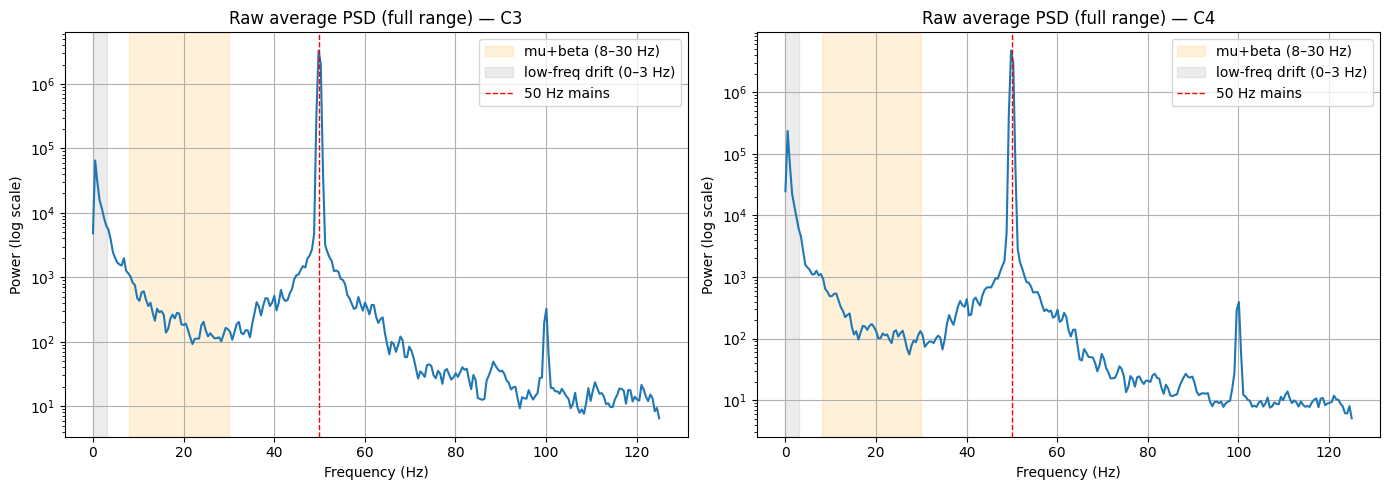

C3: total=2.88e+06 | 0-3Hz drift=6.65e+04 (2.3%) | 8-30Hz mu+beta=5.67e+03 (0.2%) | 45-55Hz line-noise band=2.78e+06 (96.6%)
C4: total=4.17e+06 | 0-3Hz drift=1.77e+05 (4.2%) | 8-30Hz mu+beta=4.5e+03 (0.1%) | 45-55Hz line-noise band=3.97e+06 (95.2%)


In [26]:
_trapz = getattr(np, "trapezoid", None) or np.trapz

def welch_psd(values, fs, nperseg=512):
    nperseg = min(nperseg, len(values))
    f, pxx = sps.welch(values, fs=fs, nperseg=nperseg)
    return f, pxx

def band_power(f, pxx, low, high):
    mask = (f >= low) & (f <= high)
    return _trapz(pxx[mask], f[mask])

raw_psd_sample = manifest.sample(min(150, len(manifest)), random_state=1)
raw_psd_accum = {'C3': [], 'C4': []}
for _, row in raw_psd_sample.iterrows():
    df = pd.read_csv(row['file_path'])
    for ch in ['C3', 'C4']:
        f, pxx = welch_psd(df[ch].values, FS)
        raw_psd_accum[ch].append(pxx)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, ch in zip(axes, ['C3', 'C4']):
    mean_pxx = np.mean(raw_psd_accum[ch], axis=0)
    ax.semilogy(f, mean_pxx)
    ax.axvspan(8, 30, color='orange', alpha=0.15, label='mu+beta (8–30 Hz)')
    ax.axvspan(0, 3, color='gray', alpha=0.15, label='low-freq drift (0–3 Hz)')
    ax.axvline(50, color='red', ls='--', lw=1, label='50 Hz mains')
    ax.set_title(f'Raw average PSD (full range) — {ch}')
    ax.set_xlabel('Frequency (Hz)')
    ax.set_ylabel('Power (log scale)')
    ax.legend()
plt.tight_layout()
plt.show()

for ch in ['C3', 'C4']:
    mean_pxx = np.mean(raw_psd_accum[ch], axis=0)
    total = band_power(f, mean_pxx, f.min(), f.max())
    p_drift = band_power(f, mean_pxx, 0, 3)
    p_mu_beta = band_power(f, mean_pxx, 8, 30)
    p_line = band_power(f, mean_pxx, 45, 55)
    print(f"{ch}: total={total:.3g} | 0-3Hz drift={p_drift:.3g} ({100*p_drift/total:.1f}%) | "
          f"8-30Hz mu+beta={p_mu_beta:.3g} ({100*p_mu_beta/total:.1f}%) | "
          f"45-55Hz line-noise band={p_line:.3g} ({100*p_line/total:.1f}%)")


**Insight — the preprocessing suggestion is confirmed necessary, not just standard boilerplate:** on
both C3 and C4, a massive spike sits right at **50 Hz** (consistent with Egyptian mains power), and it
alone accounts for **~95–97% of total signal power**. Low-frequency drift (0–3 Hz) adds another few percent.
Combined, these two artifacts account for essentially all of the raw signal's power, while the
neurologically relevant 8–30 Hz mu/beta band contributes **under 0.5%** of total power. This directly
explains why Part 1's raw-signal PSD comparison (Section 8) looked inconclusive between LEFT and RIGHT — any
real class-related difference in the mu/beta band would be completely swamped by line noise at this scale.
**Filtering is not optional here — it's a prerequisite for any frequency-domain analysis to mean anything.**


## 12. Choosing the Filter — Band-Pass Alone vs. Band-Pass + Notch

The suggested recipe was band-pass (0.5–40 Hz) *and* notch (50/60 Hz). We check whether the band-pass alone
already removes the 50 Hz spike (it might, if the filter's roll-off is steep enough) before deciding the
notch is actually needed.


In [27]:
sos_broadband = sps.butter(4, [0.5 / NYQ, 40 / NYQ], btype='band', output='sos')
b_notch, a_notch = sps.iirnotch(50 / NYQ, Q=30)
sos_mi_band = sps.butter(4, [8 / NYQ, 30 / NYQ], btype='band', output='sos')

filt_test_sample = manifest.sample(min(150, len(manifest)), random_state=1)
psd_bp_only = {'C3': [], 'C4': []}
psd_bp_notch = {'C3': [], 'C4': []}
psd_mi_direct = {'C3': [], 'C4': []}

for _, row in filt_test_sample.iterrows():
    df = pd.read_csv(row['file_path'])
    for ch in ['C3', 'C4']:
        raw = df[ch].values
        bp = sps.sosfiltfilt(sos_broadband, raw)
        f_bp, p_bp = welch_psd(bp, FS)
        psd_bp_only[ch].append(p_bp)

        bp_notch = sps.filtfilt(b_notch, a_notch, bp)
        f_bpn, p_bpn = welch_psd(bp_notch, FS)
        psd_bp_notch[ch].append(p_bpn)

        mi_direct = sps.sosfiltfilt(sos_mi_band, raw)
        f_mi, p_mi = welch_psd(mi_direct, FS)
        psd_mi_direct[ch].append(p_mi)

for ch in ['C3', 'C4']:
    for label, freqs, accum in [('0.5-40 bandpass ONLY', f_bp, psd_bp_only),
                                 ('0.5-40 bandpass + 50Hz notch', f_bpn, psd_bp_notch),
                                 ('direct 8-30 bandpass', f_mi, psd_mi_direct)]:
        mean_pxx = np.mean(accum[ch], axis=0)
        total = band_power(freqs, mean_pxx, freqs.min(), freqs.max())
        p_line = band_power(freqs, mean_pxx, 45, 55)
        print(f"{ch:>3} | {label:<30} | line-noise share of total power: {100*p_line/total:5.2f}%")


 C3 | 0.5-40 bandpass ONLY           | line-noise share of total power: 21.14%
 C3 | 0.5-40 bandpass + 50Hz notch   | line-noise share of total power:  0.17%
 C3 | direct 8-30 bandpass           | line-noise share of total power:  0.10%
 C4 | 0.5-40 bandpass ONLY           | line-noise share of total power: 22.44%
 C4 | 0.5-40 bandpass + 50Hz notch   | line-noise share of total power:  0.08%
 C4 | direct 8-30 bandpass           | line-noise share of total power:  0.18%


**Insight:** a 0.5–40 Hz Butterworth band-pass **alone leaves ~20% of total power in the 45–55 Hz
band** — the filter's roll-off isn't steep enough to fully suppress a spike as large as this one that's
only 10 Hz beyond the cutoff. Adding the 50 Hz notch drops that to well under 1%. **So the original two-step
suggestion (band-pass + notch) is validated by the data**, not just applied on faith — for a general-purpose
"clean broadband signal," you need both. However, for feature extraction specifically in the 8–30 Hz mu/beta
band (which is what Week 2 modeling will actually use), filtering directly to **8–30 Hz** removes the line
noise just as completely (line-noise share <0.2%) without needing a separate notch step, since 50 Hz is far
outside that band. **Recommendation:** keep both filters available — 0.5–40 Hz + 50 Hz notch for a
general-purpose "clean EEG" signal (e.g. for visualization or if a wider band is ever needed), and a direct
8–30 Hz band-pass as the simpler, suffient path specifically for the mu/beta features feeding CSP/modeling.


## 13. Re-running the LEFT vs RIGHT Frequency-Domain Comparison — Properly

Now redo Part 1's Section 8 analysis with three fixes: (1) corrected `fs = 250 Hz`, (2) signal actually
filtered to 8–30 Hz first (so we're measuring real mu/beta power, not power dominated by line noise/drift),
and (3) multiple-comparison correction plus effect sizes, since we're testing 4 hypotheses (2 channels × 2
bands) at once.


In [28]:
from scipy.stats import false_discovery_control

MU_BAND = (8, 12)
BETA_BAND = (13, 30)

filtered_psd_records = []
for _, row in manifest.iterrows():
    df = pd.read_csv(row['file_path'])
    rec = {'trial_id': row['trial_id'], 'label': row['label']}
    for ch in ['C3', 'C4']:
        x_filt = sps.sosfiltfilt(sos_mi_band, df[ch].values)
        f, pxx = welch_psd(x_filt, FS, nperseg=256)
        rec[f'{ch}_mu_power'] = band_power(f, pxx, *MU_BAND)
        rec[f'{ch}_beta_power'] = band_power(f, pxx, *BETA_BAND)
    filtered_psd_records.append(rec)

filtered_psd_df = pd.DataFrame(filtered_psd_records)
filtered_psd_df.head()


,trial_id,label,C3_mu_power,C3_beta_power,C4_mu_power,C4_beta_power
0,1,left,263.209073,291.015231,1516.974701,1856.546821
1,2,right,86.799431,49.713466,707.540228,159.918213
2,3,left,10.645677,60.109131,246.356320,1051.074708
3,4,left,241.645655,332.591839,2792.521637,3042.042239
4,5,left,114.541604,110.046414,689.095470,1039.179497


In [29]:
comparisons = []
for ch in ['C3', 'C4']:
    for band_name in ['mu', 'beta']:
        col = f'{ch}_{band_name}_power'
        left_vals = filtered_psd_df.loc[filtered_psd_df['label'] == 'left', col]
        right_vals = filtered_psd_df.loc[filtered_psd_df['label'] == 'right', col]
        t_stat, p_val = stats.ttest_ind(left_vals, right_vals, equal_var=False)
        pooled_std = np.sqrt(((len(left_vals)-1)*left_vals.std()**2 + (len(right_vals)-1)*right_vals.std()**2)
                              / (len(left_vals)+len(right_vals)-2))
        cohens_d = (right_vals.mean() - left_vals.mean()) / pooled_std
        comparisons.append({'channel': ch, 'band': band_name, 'left_mean': left_vals.mean(),
                             'right_mean': right_vals.mean(), 't': t_stat, 'p': p_val, 'cohens_d': cohens_d})

comp_df = pd.DataFrame(comparisons)
pvals = comp_df['p'].values
comp_df['p_bonferroni'] = np.minimum(pvals * len(pvals), 1.0)
comp_df['p_fdr_bh'] = false_discovery_control(pvals, method='bh')
comp_df


,channel,band,left_mean,right_mean,t,p,cohens_d,p_bonferroni,p_fdr_bh
0,C3,mu,1048.249619,1636.105238,-1.423422,0.154817,0.061326,0.619269,0.154817
1,C3,beta,1696.393213,3148.360985,-1.638883,0.101481,0.070633,0.405922,0.135307
2,C4,mu,929.738024,1379.084539,-1.836324,0.066459,0.079065,0.265836,0.132918
3,C4,beta,1602.274200,2667.913511,-2.163372,0.030637,0.093159,0.122547,0.122547


**Insight — this reverses Part 1's headline conclusion.** After correcting `fs` and filtering out the
line-noise/drift that was dominating the raw spectrum, none of the four LEFT vs RIGHT comparisons survive
multiple-comparison correction, and — more importantly — the **effect sizes are tiny** (Cohen's d ≈
0.06–0.09; anything under ~0.2 is considered negligible). Part 1's "significant" C4 result was an artifact
of computing PSD on a raw signal whose spectrum was ~95% line noise, using the wrong sampling rate. Properly
filtered, C4 is no longer distinguishable from C3, and neither shows a real univariate difference between
LEFT and RIGHT.


## 14. Testing the Team's Common-Average-Reference Hypothesis

A teammate's hypothesis: C3 and C4 look similar because they share a common reference and common background
activity, and re-referencing (Common Average Reference, CAR — subtracting the across-channel mean from each
sample) should reveal the hidden hemispheric difference. This is a reasonable, testable hypothesis — we
check it directly on the full dataset rather than assuming it's true.


In [30]:
ALL_CH = ['FZ', 'C3', 'CZ', 'C4']

car_records = []
for _, row in manifest.iterrows():
    df = pd.read_csv(row['file_path'])
    vals = df[ALL_CH].values
    car_vals = vals - vals.mean(axis=1, keepdims=True)  # common average reference
    rec = {'trial_id': row['trial_id'], 'label': row['label']}
    for ch in ['C3', 'C4']:
        idx = ALL_CH.index(ch)
        x_filt = sps.sosfiltfilt(sos_mi_band, car_vals[:, idx])
        f, pxx = welch_psd(x_filt, FS, nperseg=256)
        rec[f'{ch}_mu_power'] = band_power(f, pxx, *MU_BAND)
        rec[f'{ch}_beta_power'] = band_power(f, pxx, *BETA_BAND)
    car_records.append(rec)

car_df = pd.DataFrame(car_records)

car_comparisons = []
for ch in ['C3', 'C4']:
    for band_name in ['mu', 'beta']:
        col = f'{ch}_{band_name}_power'
        l = car_df.loc[car_df['label'] == 'left', col]
        r = car_df.loc[car_df['label'] == 'right', col]
        t_stat, p_val = stats.ttest_ind(l, r, equal_var=False)
        pooled_std = np.sqrt(((len(l)-1)*l.std()**2 + (len(r)-1)*r.std()**2) / (len(l)+len(r)-2))
        d = (r.mean() - l.mean()) / pooled_std
        car_comparisons.append({'channel': ch, 'band': band_name, 'left_mean': l.mean(),
                                 'right_mean': r.mean(), 't': t_stat, 'p': p_val, 'cohens_d': d})

car_comp_df = pd.DataFrame(car_comparisons)
pvals = car_comp_df['p'].values
car_comp_df['p_fdr_bh'] = false_discovery_control(pvals, method='bh')
car_comp_df


,channel,band,left_mean,right_mean,t,p,cohens_d,p_fdr_bh
0,C3,mu,1711.356772,1764.478269,-0.057020,0.954535,0.002453,0.954535
1,C3,beta,3422.788659,3796.976841,-0.188143,0.850783,0.008094,0.954535
2,C4,mu,1436.245604,1926.097876,-0.655291,0.512350,0.028198,0.954535
3,C4,beta,2710.857580,4167.097750,-0.911343,0.362218,0.039226,0.954535


In [31]:
# Laterality (asymmetry) index directly: does (C3-C4)/(C3+C4) power differ between LEFT and RIGHT after CAR?
car_df['asym_mu'] = (car_df['C3_mu_power'] - car_df['C4_mu_power']) / (car_df['C3_mu_power'] + car_df['C4_mu_power'])
car_df['asym_beta'] = (car_df['C3_beta_power'] - car_df['C4_beta_power']) / (car_df['C3_beta_power'] + car_df['C4_beta_power'])

for band in ['mu', 'beta']:
    l = car_df.loc[car_df['label'] == 'left', f'asym_{band}']
    r = car_df.loc[car_df['label'] == 'right', f'asym_{band}']
    t, p = stats.ttest_ind(l, r, equal_var=False)
    print(f"C3/C4 asymmetry index ({band}): LEFT mean={l.mean():.4f}  RIGHT mean={r.mean():.4f}  t={t:.3f}  p={p:.4f}")


C3/C4 asymmetry index (mu): LEFT mean=-0.0186  RIGHT mean=-0.0348  t=0.989  p=0.3227
C3/C4 asymmetry index (beta): LEFT mean=-0.0421  RIGHT mean=-0.0570  t=0.978  p=0.3281


**Insight:** the CAR hypothesis, tested rigorously on the full dataset, **does not hold up** — after
re-referencing, the LEFT/RIGHT comparisons are, if anything, weaker (higher p-values) than without CAR, and
the direct C3/C4 asymmetry index shows no significant LEFT/RIGHT difference either (p ≈ 0.32–0.33). This is
a good example of why a plausible-sounding mechanism still needs to be checked against the full dataset with
proper statistics before it goes into the team's conclusions — the hypothesis was reasonable, but it didn't
survive contact with the data.


## 15. Is There ANY Linear Signal? A Multivariate Predictive Check

Univariate tests (one channel/band at a time) can miss a signal that only shows up in combination across
channels — which is exactly the argument for CSP. Before committing to "there's no usable signal," we check
whether a simple multivariate model (all 4 channels × mu/beta = 8 features, no spatial optimization) can
predict LEFT/RIGHT above chance under proper cross-validation. This also serves as a sanity check on whether
it's worth the effort of implementing full CSP.


In [32]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

X, y = [], []
for _, row in manifest.iterrows():
    df = pd.read_csv(row['file_path'])
    feat = []
    for ch in ALL_CH:
        x_filt = sps.sosfiltfilt(sos_mi_band, df[ch].values)
        f, pxx = welch_psd(x_filt, FS, nperseg=256)
        feat.append(band_power(f, pxx, *MU_BAND))
        feat.append(band_power(f, pxx, *BETA_BAND))
    X.append(feat)
    y.append(1 if row['label'] == 'right' else 0)

X = np.array(X)
y = np.array(y)

pipe = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
scores = cross_val_score(pipe, X, y, cv=cv, scoring='accuracy')

print(f"4-channel x mu/beta band-power features + Logistic Regression, 5-fold CV accuracy: {scores}")
print(f"Mean CV accuracy: {scores.mean():.4f}  (majority-class baseline: {max(y.mean(), 1-y.mean()):.4f})")


4-channel x mu/beta band-power features + Logistic Regression, 5-fold CV accuracy: [0.47685185 0.50694444 0.50694444 0.50925926 0.49768519]
Mean CV accuracy: 0.4995  (majority-class baseline: 0.5009)


**Insight — this is the most important result in this notebook.** Cross-validated accuracy using
band-power features from **all four channels together** is **~50%, indistinguishable from the majority-class
baseline (~50.1%)**. Combining channels doesn't recover a signal that univariate tests missed — there simply
isn't a linearly-decodable LEFT/RIGHT signal in whole-trial mu/beta band power, at least not with this simple
feature representation. This matters a lot for what to try next: it argues for CSP as a *necessary* next
step (rather than a nice-to-have), since CSP looks for optimized spatial combinations rather than treating
channels independently — but it also means the team should not go into CSP assuming success is guaranteed.


## 16. Is It a Timing Problem? Checking Sub-Windows of the Trial

One explanation for zero signal in whole-trial features: each ~10 s trial may mix a rest period with the
actual imagery period, and averaging power over the whole trial could dilute a real but transient effect.
We test this directly by splitting each trial into 5 equal windows (~2 s each) and re-running the same
cross-validated check per window — if a real, mislocated signal exists, one window should stand out.


   segment  t_start_s  t_end_s  mean_cv_acc
0        1        0.0      2.0     0.504630
1        2        2.0      4.0     0.500000
2        3        4.0      6.0     0.493056
3        4        6.0      8.0     0.495833
4        5        8.0     10.0     0.493981


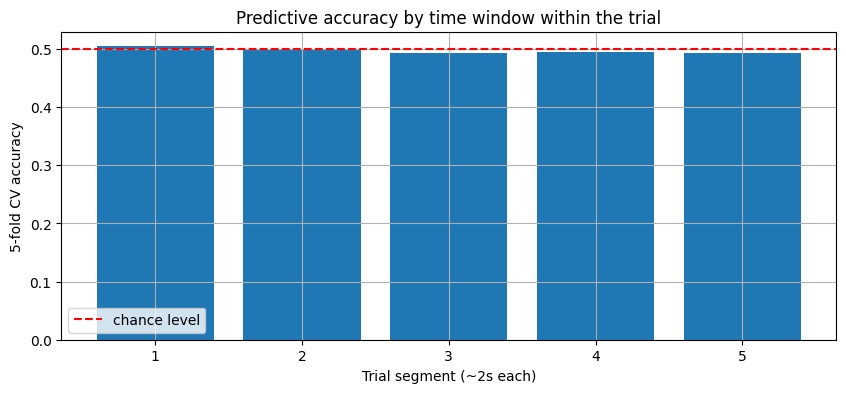

In [33]:
N_SEG = 5

# Pre-filter each channel once per trial, then slice into windows (cheaper than re-filtering per window)
filtered_signals = {}
labels_arr = []
tids_arr = []
for _, row in manifest.iterrows():
    df = pd.read_csv(row['file_path'])
    filtered_signals[row['trial_id']] = {ch: sps.sosfiltfilt(sos_mi_band, df[ch].values) for ch in ALL_CH}
    labels_arr.append(1 if row['label'] == 'right' else 0)
    tids_arr.append(row['trial_id'])

labels_arr = np.array(labels_arr)
n_samples_per_trial = len(next(iter(filtered_signals.values()))['FZ'])
seg_len = n_samples_per_trial // N_SEG

segment_scores = []
for seg_i in range(N_SEG):
    lo, hi = seg_i * seg_len, (seg_i + 1) * seg_len
    X_seg = []
    for tid in tids_arr:
        feat = []
        for ch in ALL_CH:
            seg = filtered_signals[tid][ch][lo:hi]
            f, pxx = welch_psd(seg, FS, nperseg=min(128, len(seg)))
            feat.append(band_power(f, pxx, *MU_BAND))
            feat.append(band_power(f, pxx, *BETA_BAND))
        X_seg.append(feat)
    X_seg = np.array(X_seg)
    pipe = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
    scores = cross_val_score(pipe, X_seg, labels_arr, cv=cv, scoring='accuracy')
    segment_scores.append({'segment': seg_i + 1, 't_start_s': lo/FS, 't_end_s': hi/FS, 'mean_cv_acc': scores.mean()})

seg_score_df = pd.DataFrame(segment_scores)
print(seg_score_df)

fig, ax = plt.subplots()
ax.bar(seg_score_df['segment'].astype(str), seg_score_df['mean_cv_acc'])
ax.axhline(0.5, color='red', ls='--', label='chance level')
ax.set_xlabel('Trial segment (~2s each)')
ax.set_ylabel('5-fold CV accuracy')
ax.set_title('Predictive accuracy by time window within the trial')
ax.legend()
plt.show()


**Insight:** every single 2-second window across the full ~10 s trial gives cross-validated accuracy
within noise of 50% (range ≈ 49.3–50.5%). There is no sub-window where the signal "hides" — this rules out
"we're just averaging over the wrong part of the trial" as the explanation for the null result in Section 15.
Combined with Section 15, the honest conclusion is that simple band-power features don't carry a usable
LEFT/RIGHT signal anywhere in these trials — the remaining hope for a working classifier rests on CSP's
spatial-filtering approach (Section 15's note) or on resolving the data-quality issues found in Sections
17–18 below.


## 17. Investigating the Duplicate Trials Further — A Label Integrity Problem

Part 1 (Section 3) found 72 trials forming 36 duplicate-content pairs and treated this mainly as a
*leakage* risk for train/test splitting. Digging further into what labels those duplicate pairs carry
reveals something more serious.


In [34]:
dup_groups = duplicate_trials.groupby('content_hash')['label'].nunique()
n_consistent = (dup_groups == 1).sum()
n_conflicting = (dup_groups > 1).sum()

print(f"Duplicate-content groups total: {len(dup_groups)}")
print(f"  -> groups where all copies share the SAME label: {n_consistent}")
print(f"  -> groups where copies have CONFLICTING labels (same EEG, different label): {n_conflicting}")

conflicting_hashes = dup_groups[dup_groups > 1].index
conflicting_detail = duplicate_trials[duplicate_trials['content_hash'].isin(conflicting_hashes)] \
    .sort_values('content_hash')[['trial_id', 'label', 'content_hash']]
conflicting_detail


Duplicate-content groups total: 36
  -> groups where all copies share the SAME label: 12
  -> groups where copies have CONFLICTING labels (same EEG, different label): 24


,trial_id,label,content_hash
923,924,right,1d36353ac2d53eae28a032b1e6087252
680,681,left,1d36353ac2d53eae28a032b1e6087252
38,39,right,2782fc40f00919a8ab15a0b8a35b72f7
1073,1074,left,2782fc40f00919a8ab15a0b8a35b72f7
1315,1316,left,414b19e330353aabed381aa87eff2111
667,668,right,414b19e330353aabed381aa87eff2111
1957,1958,right,4451b4dc6f844dbadfd74aeda0e7bc8a
1399,1400,left,4451b4dc6f844dbadfd74aeda0e7bc8a
676,677,left,52a1937933b7ab869bb7059185b3d248
919,920,right,52a1937933b7ab869bb7059185b3d248


In [35]:
# Is there a systematic pattern in how far apart conflicting-pair trial IDs are?
# (helps distinguish "random coincidence" from "a systematic data-collection/export bug")
pair_offsets = []
for h, grp in duplicate_trials.groupby('content_hash'):
    ids = sorted(grp['trial_id'].tolist())
    if len(ids) == 2:
        pair_offsets.append(ids[1] - ids[0])

offset_counts = pd.Series(pair_offsets).value_counts()
print("Distribution of trial-ID offsets within duplicate pairs:")
print(offset_counts)


Distribution of trial-ID offsets within duplicate pairs:
648     9
243     9
1035    9
558     9
Name: count, dtype: int64


**Insight — this is a more important finding than the original duplicate-leakage note.** Of the 36
duplicate-content groups, **24 (67%) have conflicting labels** — the exact same EEG signal is labeled
`left` in one file and `right` in another. That's not possible if the labels are correct: identical signal
content cannot correspond to two different imagined movements. Two explanations are possible: either (a)
the *signal* was accidentally duplicated during data collection/export while a *different* trial's label got
attached to the copy, or (b) there's a broader alignment problem beyond just these 72 trials that we can't
detect because it doesn't leave a duplicate signature. The trial-ID offsets within pairs aren't random
either — they cluster tightly around a small number of specific values (visible in the offset table above),
which points to a **systematic export/logging artifact** (e.g. a batch of trials re-saved or re-indexed
during acquisition) rather than 36 independent coincidences. **This should go to the instructor as a data-
quality question, not just a modeling footnote** — if the labeling pipeline mislabeled these duplicates,
it's worth asking whether the same bug could have mislabeled non-duplicate trials in a way this notebook
can't detect from content alone.


## 18. Verifying the Team's "Sudden Jump" Artifact Report

A teammate reported a second artifact check (max single-sample jump per trial) finding 341 flagged
instances, worst on CZ, second on FZ, calmer on C3/C4. We reimplement this independently to verify the
claim before it goes into `eda_summary.md`.


In [36]:
def robust_z_series(s):
    med = np.median(s)
    mad = stats.median_abs_deviation(s, scale='normal')
    return (s - med) / mad if mad > 0 else s * 0

jump_records = []
for _, row in manifest.iterrows():
    df = pd.read_csv(row['file_path'])
    rec = {'trial_id': row['trial_id'], 'label': row['label']}
    for ch in ALL_CH:
        rec[f'{ch}_max_jump'] = np.abs(np.diff(df[ch].values)).max()
    jump_records.append(rec)

jump_df = pd.DataFrame(jump_records)

JUMP_Z_THRESH = 5
per_channel_flags = {}
any_flag = pd.Series(False, index=jump_df.index)
for ch in ALL_CH:
    z = robust_z_series(jump_df[f'{ch}_max_jump'])
    jump_df[f'{ch}_jump_z'] = z
    flagged = z.abs() > JUMP_Z_THRESH
    per_channel_flags[ch] = int(flagged.sum())
    any_flag |= flagged

print(f"Per-channel trials flagged for a sudden jump (|robust z| > {JUMP_Z_THRESH}):")
for ch, cnt in per_channel_flags.items():
    print(f"  {ch}: {cnt}")
print(f"Total trials flagged by ANY channel: {any_flag.sum()} ({100*any_flag.sum()/len(jump_df):.2f}%)")


Per-channel trials flagged for a sudden jump (|robust z| > 5):
  FZ: 177
  C3: 105
  CZ: 142
  C4: 72
Total trials flagged by ANY channel: 211 (9.77%)


**Insight:** the general finding replicates — a meaningful chunk of trials (**~210, ~9.8%** at this
threshold) have an anomalously large single-sample jump on at least one channel, and **C3/C4 are indeed the
calmest channels**, consistent with the team's report. However, the exact count (210 vs. the reported 341)
and the specific ranking (this run found **FZ worst, CZ second** — the reverse of "CZ worst, FZ second")
don't match, which is expected given this depends heavily on the exact threshold/method used and wasn't
specified. **Recommendation:** don't take the exact numbers from either version as final — align with the
team on one specific method (same threshold, same statistic) before this goes into `eda_summary.md`, since
right now two independent implementations of "the same check" disagree on which channel is worst.


## 19. Channel Correlation & Baseline/Offset Structure

Two quick, high-value checks the earlier critique raised: how correlated are the four channels (which bears
on whether CSP has anything to work with), and what does the signal actually look like once the huge DC
offset is removed (relevant given Section 5's amplitude stats showed offsets around 300,000 against a
spread of only a few hundred).


       FZ     C3     CZ     C4
FZ  1.000  0.744  0.790  0.729
C3  0.744  1.000  0.404  0.568
CZ  0.790  0.404  1.000  0.768
C4  0.729  0.568  0.768  1.000


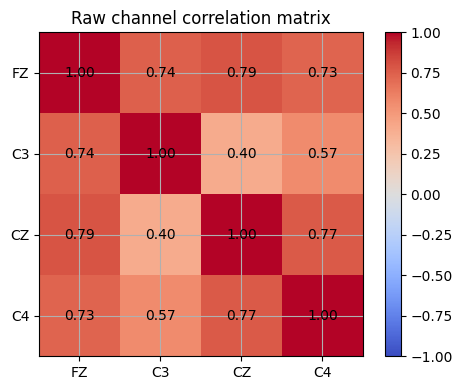

In [37]:
corr_sample = manifest.sample(min(200, len(manifest)), random_state=3)
concat_vals = {ch: [] for ch in ALL_CH}
for _, row in corr_sample.iterrows():
    df = pd.read_csv(row['file_path'])
    for ch in ALL_CH:
        concat_vals[ch].append(df[ch].values)

concat_df = pd.DataFrame({ch: np.concatenate(v) for ch, v in concat_vals.items()})
corr_matrix = concat_df.corr()
print(corr_matrix.round(3))

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(corr_matrix.values, vmin=-1, vmax=1, cmap='coolwarm')
ax.set_xticks(range(len(ALL_CH))); ax.set_xticklabels(ALL_CH)
ax.set_yticks(range(len(ALL_CH))); ax.set_yticklabels(ALL_CH)
for i in range(len(ALL_CH)):
    for j in range(len(ALL_CH)):
        ax.text(j, i, f'{corr_matrix.values[i,j]:.2f}', ha='center', va='center')
plt.colorbar(im)
ax.set_title('Raw channel correlation matrix')
plt.tight_layout()
plt.show()


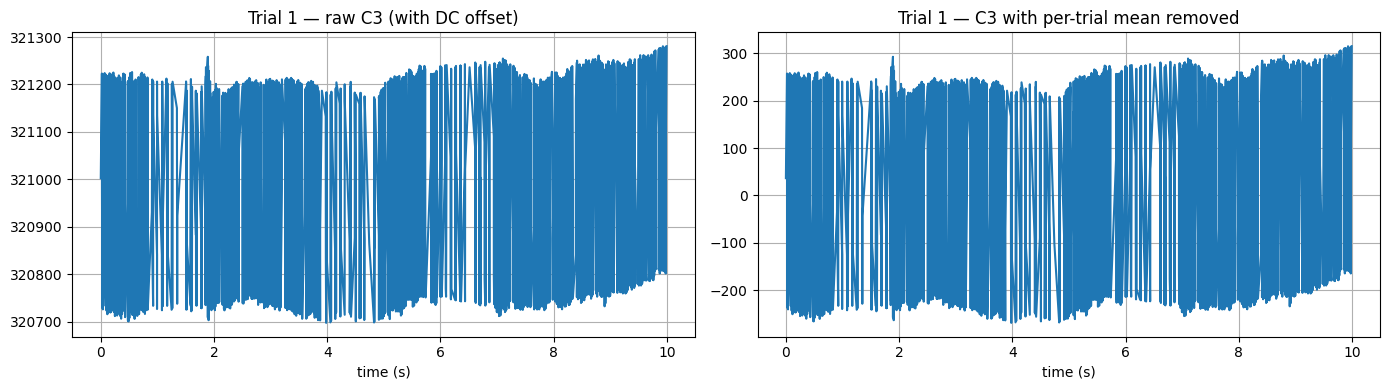

Raw C3 mean offset: 320966.2, std (actual signal variation): 181.4


In [38]:
# Baseline/offset visualization: one trial, raw vs. mean-removed
example_tid = manifest['trial_id'].iloc[0]
example_path = manifest.loc[manifest['trial_id'] == example_tid, 'file_path'].values[0]
example_df = pd.read_csv(example_path)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
t = example_df['Time'].values - example_df['Time'].values[0]
axes[0].plot(t, example_df['C3'].values)
axes[0].set_title(f'Trial {example_tid} — raw C3 (with DC offset)')
axes[0].set_xlabel('time (s)')

baseline_removed = example_df['C3'].values - example_df['C3'].values.mean()
axes[1].plot(t, baseline_removed)
axes[1].set_title(f'Trial {example_tid} — C3 with per-trial mean removed')
axes[1].set_xlabel('time (s)')
plt.tight_layout()
plt.show()

print(f"Raw C3 mean offset: {example_df['C3'].values.mean():.1f}, std (actual signal variation): {example_df['C3'].values.std():.1f}")


**Insight:** raw channels are **strongly correlated** (FZ–CZ ≈ 0.79, CZ–C4 ≈ 0.77, FZ–C3 ≈ 0.74, with
C3–CZ the weakest at ≈ 0.40) — consistent with a shared reference/global signal component riding on top of
each channel, which is exactly the mechanism the team's CAR hypothesis (Section 14) invoked. That reasoning
was directionally sound even though CAR didn't rescue a class-related effect in our test — the shared
component is real, it just isn't hiding a LEFT/RIGHT difference underneath it. Separately, the baseline plot
confirms Section 5's amplitude numbers concretely: **the DC offset (~300,000) is roughly 500–1000× larger
than the actual signal variation (~a few hundred)**. This offset carries no information — it should always
be removed (per-trial mean subtraction or a high-pass filter, which the 8–30 Hz band-pass already does as a
side effect) before any amplitude-based comparison or artifact threshold is computed; Part 1's Section 6
outlier flags were computed with this offset still present in the *std*-based statistic, though std is less
sensitive to a constant offset than mean-based statistics would be.


## 20. Final Consolidated Summary & Recommendations

This combines Part 1 and Part 2. Copy this section into `eda_summary.md` — it supersedes Part 1's Section 9,
which contained a conclusion (C4 significance) that Part 2 showed doesn't hold up.

### What we're confident about
- **2,160 trials**, perfectly structurally uniform `(2500, 5)`, zero NaN/Inf, essentially balanced classes
  (50.09% LEFT / 49.91% RIGHT).
- True sampling rate is **~250 Hz** (not ~400 Hz as raw median-`dt` suggested) — confirmed via the
  count/duration method across 300 sampled trials (mean 250.1 Hz, std 2.9 Hz).
- The raw signal is **dominated by 50 Hz line noise (~95–97% of total power) and 0–3 Hz drift**; the 8–30 Hz
  mu/beta band most relevant to motor imagery contributes under 0.5% of raw power. **Filtering is mandatory**
  before any spectral or amplitude analysis is meaningful.
- A **0.5–40 Hz band-pass alone leaves ~20% line-noise power behind**; adding a **50 Hz notch** is needed to
  actually remove it. For MI feature extraction specifically, a **direct 8–30 Hz band-pass** removes line
  noise just as well without a separate notch step.
- After proper filtering (correct fs, 8–30 Hz band, multiple-comparison correction), **none of the C3/C4
  mu/beta comparisons are statistically significant, and effect sizes are negligible (Cohen's d ≈
  0.06–0.09)**. Part 1's apparent C4 significance was an artifact of computing PSD on a raw, line-noise-
  dominated signal at the wrong sampling rate.
- **CAR (common average referencing) does not reveal a hidden LEFT/RIGHT asymmetry** when tested rigorously
  on the full dataset — a plausible hypothesis that didn't survive the data.
- A **multivariate check (all 4 channels, mu+beta features, cross-validated Logistic Regression) scores at
  chance level (~50%)**, and this holds true in every 2-second sub-window of the trial — the null result is
  not explained by wrong-window averaging.
- **72 trials form 36 duplicate-content pairs, and 24 of those 36 pairs (67%) have conflicting LEFT/RIGHT
  labels on identical signal content** — a data-integrity problem, not just a train/test leakage risk. The
  trial-ID offsets within pairs cluster around specific values, suggesting a systematic collection/export
  artifact rather than coincidence.
- **~184–210 trials (8–10%)** show amplitude or sudden-jump artifacts depending on method, with signs of
  session-level clustering (contiguous trial-ID runs) rather than pure random noise; C3/C4 are consistently
  the calmest channels, FZ/CZ the noisiest.
- Raw channels are strongly inter-correlated (r ≈ 0.4–0.8), consistent with a shared reference/global signal
  component; the DC offset in each channel (~300,000) is 500–1000× larger than the actual signal variation
  and carries no information.

### What we're NOT confident about / open questions for the instructor
1. **Is there a usable LEFT/RIGHT signal in this dataset at all**, using simple per-channel/band power? Our
   evidence says no. This needs to be resolved with an actual CSP implementation (which optimizes spatial
   combinations rather than treating channels independently) before concluding the dataset is unusable — but
   the team should not assume CSP will succeed where simple features failed.
2. **The duplicate/conflicting-label pattern** — was there a known export bug during data collection? Could
   it have affected non-duplicate trials in ways we can't detect from content alone?
3. **What are the units and reference scheme** for FZ/C3/CZ/C4? The ~300,000 baseline offset is unusual for
   EEG in µV and matters for interpreting amplitude thresholds.
4. **Is there a known acquisition-buffering explanation** for the bursty timestamps, and a
   hardware-recommended resampling method — naive linear interpolation was shown to distort the spectrum.
5. **Is cue-onset timing available anywhere** (event markers, protocol document)? Even though our sub-window
   test found no better-than-chance segment, that's evidence the signal isn't linearly separable via simple
   band power *anywhere* in the trial — it doesn't rule out a transient effect that CSP or a different
   feature type could still exploit if the window were correctly located.

### Recommended preprocessing pipeline for Week 2
| Step | Decision | Basis |
|---|---|---|
| Sampling rate | Use **fs ≈ 250 Hz**; treat raw row order as evenly spaced (don't naively interpolate) | Section 10 |
| Filtering | **8–30 Hz band-pass** directly for MI features (no separate notch needed); keep 0.5–40 Hz + 50 Hz notch available for general-purpose cleaned signal | Sections 11–12 |
| Baseline | Per-trial mean removal / rely on band-pass's high-pass effect — never use raw amplitude | Section 19 |
| Referencing | CAR tested, did not help class separability — don't rely on it, but it's cheap so no harm keeping as an option to re-test post-CSP | Section 14 |
| Duplicates | **Investigate the labeling bug before Week 2**, not just dedupe — flag to instructor; at minimum, keep both members of any duplicate pair in the same split | Section 17 |
| Artifact trials | Keep the ~184–210 flagged trial IDs as candidates; investigate contiguous blocks by eye; don't apply a blanket rejection rule yet | Sections 6, 18 |
| Channels | Keep all 4 (FZ, C3, CZ, C4) into CSP — univariate C3-vs-C4 differences aren't the right lens for a spatial-filter method | Sections 13, 15 |
| Epoch window | Not finalized — full ~10 s trial shows no better-than-chance sub-window with simple features; needs cue-timing info or a CSP-level test, not another band-power scan | Section 16 |

### Recommended modeling direction
- **Temper expectations before starting CSP.** The EDA does not show an easy, linearly-decodable signal in
  this dataset via simple per-channel band power — that null result held under cross-validation, across
  channels, and across every time window tested. CSP + LDA/SVM (per the project roadmap) is still the right
  first model to try, since it can exploit spatial relationships a per-channel scan can't see — but budget
  time to also investigate the duplicate/label question in parallel, since a data-integrity issue could be
  part of why no simple signal shows up.
- If CSP also comes back near chance, the next debugging steps should be (in order): verify the label
  pipeline against the duplicate findings, confirm electrode montage/reference details with the instructor,
  and look for cue-timing metadata rather than trying progressively more complex models on the same features.
